# 라이브러리

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from sklearn.linear_model import LinearRegression
import networkx as nx

# 데이터

### 데이터 개념

#### 레코드 데이터

In [2]:
records = {
    "Tid": [1,2,3,4,5,6,7,8,9,10],
    "Refund": ["yes","no","no","yes","no","no","yes","no","no","no"],
    "Mar": ["single","married","single","married","divorced",
            "married","divorced","single","married","single"],
    "Tax": ["125K","100K","70K","120K","95K","60K","220K","85K","75K","90K"],
    "Cheat": ["no","no","no","no","yes","no","no","yes","no","yes"]
}

records = pd.DataFrame(records)
# print(records)

records['Refund'] = records['Refund'].map({"yes": 1, "no": 0})
records["Cheat"] = records["Cheat"].map({"yes": 1, "no": 0})
records['Mar'] = records['Mar'].map({"single": 0, "married": 1, "divorced": 2})
records['Tax'] = records['Tax'].str.replace("K", "000", regex=False).astype("uint")
print(records)

   Tid  Refund  Mar     Tax  Cheat
0    1       1    0  125000      0
1    2       0    1  100000      0
2    3       0    0   70000      0
3    4       1    1  120000      0
4    5       0    2   95000      1
5    6       0    1   60000      0
6    7       1    2  220000      0
7    8       0    0   85000      1
8    9       0    1   75000      0
9   10       0    0   90000      1


#### 트랜젝션 데이터

In [7]:
transactions = {
    1: ["빵", "콜라", "우유"],
    2: ["맥주", "빵"],
    3: ["맥주", "콜라", "기저귀", "우유"],
    4: ["맥주", "빵", "기저귀", "우유"],
    5: ["콜라", "기저귀", "우유"]
}

# transactions = pd.DataFrame(transactions)
# print(transactions)

# 아이템
unique_items = []
for basket in transactions.values():
    # print(basket)
    for item in basket:
        unique_items.append(item)
print(unique_items)

unique_items = set(unique_items)
print(unique_items)

num = len(transactions)
dim = len(unique_items)

print(num,dim)
mat = np.zeros((num,dim))

for i, (tid, basket) in enumerate(transactions.items()):
    for j, item in enumerate(unique_items):
        if item in basket:
            mat[i,j] = 1

print(pd.DataFrame(mat))

['빵', '콜라', '우유', '맥주', '빵', '맥주', '콜라', '기저귀', '우유', '맥주', '빵', '기저귀', '우유', '콜라', '기저귀', '우유']
{'맥주', '콜라', '우유', '빵', '기저귀'}
5 5
     0    1    2    3    4
0  0.0  1.0  1.0  1.0  0.0
1  1.0  0.0  0.0  1.0  0.0
2  1.0  1.0  1.0  0.0  1.0
3  1.0  0.0  1.0  1.0  1.0
4  0.0  1.0  1.0  0.0  1.0


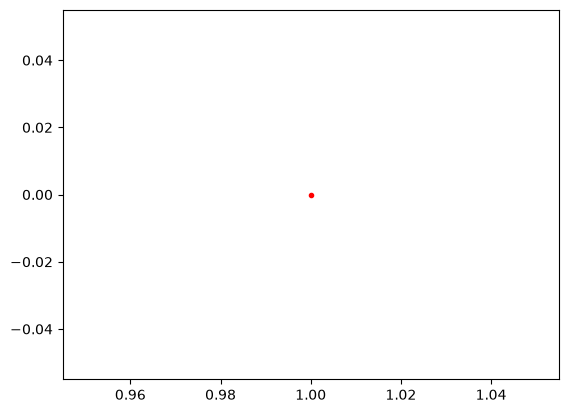

In [5]:
plt.plot(mat[1,0], mat[1,1], 'r.')

In [ ]:
# {'맥주', '콜라', '우유', '빵', '기저귀'}

corr = np.corrcoef(mat)
print(corr)

[[ 1.         -0.16666667 -0.40824829 -0.40824829  0.16666667]
 [-0.16666667  1.         -0.61237244  0.40824829 -1.        ]
 [-0.40824829 -0.61237244  1.         -0.25        0.61237244]
 [-0.40824829  0.40824829 -0.25        1.         -0.40824829]
 [ 0.16666667 -1.          0.61237244 -0.40824829  1.        ]]


#### 문서 데이터

In [18]:
# 문서 데이터
docs = {
    1 : "먹고 싶은 사과",
    2 : "먹고 싶은 바나나",
    3 : "길고 노란 바나나 바나나",
    4 : "저는 과일이 좋아요"
}

print(docs)

tok_docs = {}
for doc_id, text in docs.items():
    tokens = text.split()
    tok_docs[doc_id] = tokens
print(tok_docs)


unique_items = []
for basket in tok_docs.values():
    # print(basket)
    for item in basket:
        unique_items.append(item)
print(unique_items)

unique_items = set(unique_items)
print(unique_items)

num = len(tok_docs)
dim = len(unique_items)

print(num,dim)
mat = np.zeros((num,dim))

print(mat)

for i, (tid, basket) in enumerate(tok_docs.items()):
    for j, item in enumerate(unique_items):
        if item in basket:
            mat[i,j] = basket.count(item)

print(pd.DataFrame(mat))


corr = np.corrcoef(mat)
print(corr)

{1: '먹고 싶은 사과', 2: '먹고 싶은 바나나', 3: '길고 노란 바나나 바나나', 4: '저는 과일이 좋아요'}
{1: ['먹고', '싶은', '사과'], 2: ['먹고', '싶은', '바나나'], 3: ['길고', '노란', '바나나', '바나나'], 4: ['저는', '과일이', '좋아요']}
['먹고', '싶은', '사과', '먹고', '싶은', '바나나', '길고', '노란', '바나나', '바나나', '저는', '과일이', '좋아요']
{'사과', '길고', '바나나', '좋아요', '과일이', '저는', '노란', '싶은', '먹고'}
4 9
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]
     0    1    2    3    4    5    6    7    8
0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0
1  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  1.0
2  0.0  1.0  2.0  0.0  0.0  0.0  1.0  0.0  0.0
3  0.0  0.0  0.0  1.0  1.0  1.0  0.0  0.0  0.0
[[ 1.          0.5        -0.45883147 -0.5       ]
 [ 0.5         1.          0.22941573 -0.5       ]
 [-0.45883147  0.22941573  1.         -0.45883147]
 [-0.5        -0.5        -0.45883147  1.        ]]


#### 그래프 데이터

In [25]:
graph = {
    "A": {"B": 1},
    "B": {"A": 1, "B": 1, "C": 1, "D": 1},
    "C": {"B": 1, "E": 1},
    "D": {"B": 1, "E": 1, "F": 1},
    "E": {"C": 1, "D": 1},
    "F": {"D": 1, "F": 1}
}

nodes = sorted(graph.keys())
print(nodes)

num = len(nodes)
dim = len(nodes)

data = np.zeros((num,dim))
for i, u in enumerate(nodes):
    for j, v in enumerate(nodes):
        for v, w in graph[u].items():
            j = nodes.index(v)
            data[i,j] = w


print(data)

['A', 'B', 'C', 'D', 'E', 'F']
[[0. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 1. 1.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 1.]]


#### 시계열 데이터

In [28]:
price = {
    "삼성": [250, 200, 100, 50],
    "LG": [50, 100, 75, 100],
    "SK": [200, 250, 250, 200]
}

data = pd.DataFrame(price)

print(data)    

    삼성   LG   SK
0  250   50  200
1  200  100  250
2  100   75  250
3   50  100  200


##### 회귀분석

[[250 200 100  50]
 [ 50 100  75 100]
 [200 250 250 200]]


/home/vscode/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/vscode/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


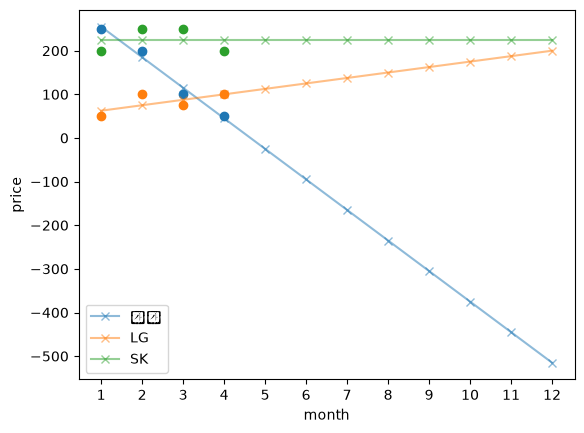

In [31]:
data = np.array(list(price.values()))
print(data)


x = np.array([[1, 2, 3, 4]]).T  # 독립변수 (4x1)

# 기업별 회귀분석 및 시각화
for i, key in enumerate(price.keys()):
    y = data[i, :]
    
    # 회귀모델 학습
    model = LinearRegression()
    model.fit(x, y)
    
    # 1~5 구간 예측값
    x_extended = np.array([[1,2,3,4,5,6,7,8,9,10,11,12]]).T
    y_extended = model.predict(x_extended)
    
    # 실제 데이터 + 예측 데이터 시각화
    plt.scatter(x, y)
    plt.plot(x_extended.ravel(), y_extended, marker="x", label=key, alpha=0.5)

plt.xlabel("month")
plt.ylabel("price")
plt.xticks(range(1, 13, 1))
plt.legend()
plt.show()

#### 이미지 데이터

In [ ]:
from pathlib import Path

folder = Path("mnist_sample")
png_files = list(folder.glob("*.png"))

print(data)